In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print(os.getcwd())   # should be D:\project_data

from pathlib import Path

for root in ["data/raw/kaggle_2d_shapes", "data/raw/kaggle_simple_shapes"]:
    print("=====", root)
    for p in sorted(Path(root).rglob("*")):
        if p.is_dir():
            files = [f for f in p.iterdir() if f.is_file()]
            print(f"{p}  ({len(files)} files)  e.g. {[f.name for f in files[:3]]}")

d:\project_data
===== data/raw/kaggle_2d_shapes
data\raw\kaggle_2d_shapes\circle  (50000 files)  e.g. ['circle_1.png', 'circle_10.png', 'circle_100.png']
data\raw\kaggle_2d_shapes\decagon  (50000 files)  e.g. ['decagon_1.png', 'decagon_10.png', 'decagon_100.png']
data\raw\kaggle_2d_shapes\heptagon  (50000 files)  e.g. ['heptagon_1.png', 'heptagon_10.png', 'heptagon_100.png']
data\raw\kaggle_2d_shapes\hexagon  (50000 files)  e.g. ['hexagon_1.png', 'hexagon_10.png', 'hexagon_100.png']
data\raw\kaggle_2d_shapes\kite  (50000 files)  e.g. ['kite_1.png', 'kite_10.png', 'kite_100.png']
data\raw\kaggle_2d_shapes\nonagon  (50000 files)  e.g. ['nonagon_1.png', 'nonagon_10.png', 'nonagon_100.png']
data\raw\kaggle_2d_shapes\octagon  (50000 files)  e.g. ['octagon_1.png', 'octagon_10.png', 'octagon_100.png']
data\raw\kaggle_2d_shapes\oval  (50000 files)  e.g. ['oval_1.png', 'oval_10.png', 'oval_100.png']
data\raw\kaggle_2d_shapes\parallelogram  (50000 files)  e.g. ['parallelogram_1.png', 'parallelog

In [2]:
import cv2
import numpy as np
import pandas as pd

CLASSES = ["circle", "triangle", "square", "pentagon", "hexagon"]
SIZE = 64

meta = pd.read_csv("data/generated/single_metadata.csv")
meta["source"] = "generated"


def load_gray(path, size=SIZE):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)


X = np.stack([load_gray(p) for p in meta["path"]])   # (N, 64, 64) uint8
y = meta["label"].map({c: i for i, c in enumerate(CLASSES)}).to_numpy()

print(X.shape, y.shape)
print(meta.head())

train = (meta["split"] == "train").to_numpy()
X_train, y_train = X[train], y[train]
X_test, y_test = X[~train], y[~train]
print(X_train.shape, X_test.shape)

(1250, 64, 64) (1250,)
                                                path     label  split  width  \
0  data\generated\single\train\triangle\triangle_...  triangle  train    128   
1  data\generated\single\train\triangle\triangle_...  triangle  train    128   
2  data\generated\single\train\triangle\triangle_...  triangle  train    128   
3  data\generated\single\train\triangle\triangle_...  triangle  train    128   
4  data\generated\single\train\triangle\triangle_...  triangle  train    128   

   height     source  
0     128  generated  
1     128  generated  
2     128  generated  
3     128  generated  
4     128  generated  
(1000, 64, 64) (250, 64, 64)


In [3]:
np.savez_compressed("data/generated/shapes_64.npz",
                    X_train=X_train, y_train=y_train,
                    X_test=X_test, y_test=y_test)

In [4]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
from pathlib import Path

CLASSES = ["circle", "triangle", "square", "pentagon", "hexagon"]
N_2D = 400       # images per class from the 17-shapes dataset
N_SIMPLE = 300   # images per class from the simple-shapes dataset
rng = np.random.default_rng(42)

rows = []

# dataset 1: folder names are already lowercase
for c in CLASSES:
    files = sorted(Path(f"data/raw/kaggle_2d_shapes/{c}").glob("*.png"))
    pick = rng.choice(len(files), N_2D, replace=False)
    rows += [{"path": str(files[i]), "label": c, "source": "kaggle_2d"} for i in pick]

# dataset 2: folder names are capitalized, only 3 classes
for c in ["circle", "square", "triangle"]:
    files = sorted(Path(f"data/raw/kaggle_simple_shapes/{c.capitalize()}").glob("*.png"))
    pick = rng.choice(len(files), N_SIMPLE, replace=False)
    rows += [{"path": str(files[i]), "label": c, "source": "kaggle_simple"} for i in pick]

kaggle = pd.DataFrame(rows)
print(kaggle.groupby(["source", "label"]).size())

source         label   
kaggle_2d      circle      400
               hexagon     400
               pentagon    400
               square      400
               triangle    400
kaggle_simple  circle      300
               square      300
               triangle    300
dtype: int64


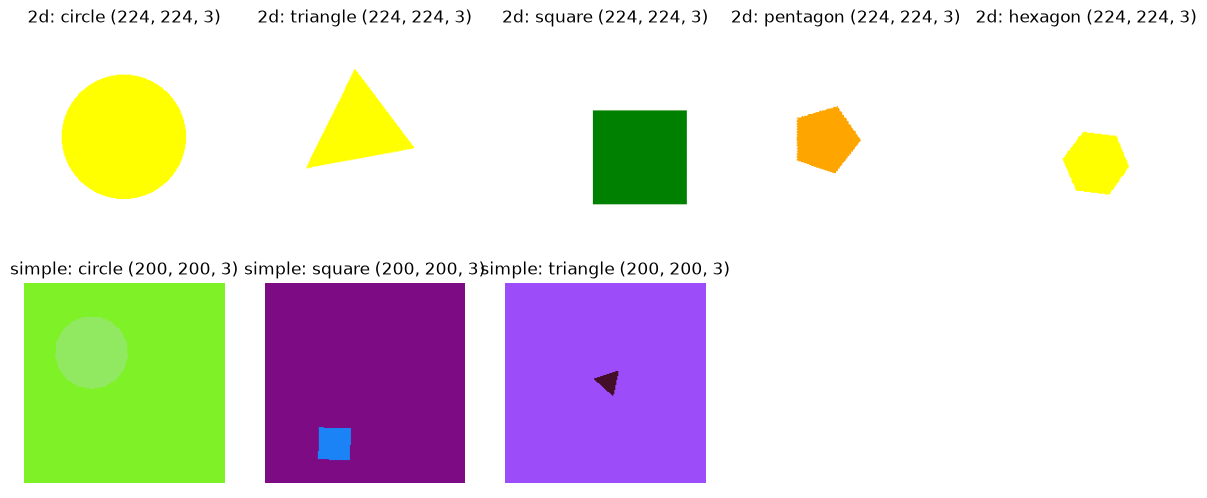

In [5]:
import cv2
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, (_, r) in zip(axes[0], kaggle[kaggle.source == "kaggle_2d"].groupby("label").head(1).iterrows()):
    img = cv2.imread(r.path)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(f"2d: {r.label} {img.shape}"); ax.axis("off")
for ax, (_, r) in zip(axes[1], kaggle[kaggle.source == "kaggle_simple"].groupby("label").head(1).iterrows()):
    img = cv2.imread(r.path)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(f"simple: {r.label} {img.shape}"); ax.axis("off")
for ax in axes[1][3:]:
    ax.axis("off")
plt.show()


In [6]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

CLASSES = ["circle", "triangle", "square", "pentagon", "hexagon"]
SIZE, PAD = 64, 4


def shape_mask(img_bgr):
    """Binary mask (255 = shape) from colour distance to the background."""
    img = cv2.GaussianBlur(img_bgr, (5, 5), 0)
    border = np.concatenate([img[0], img[-1], img[:, 0], img[:, -1]])
    bg = np.median(border, axis=0)
    dist = np.linalg.norm(img.astype(np.float32) - bg, axis=2)
    dist = np.clip(dist * (255 / max(dist.max(), 1)), 0, 255).astype(np.uint8)
    _, mask = cv2.threshold(dist, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return mask


def silhouette(path, size=SIZE, pad=PAD):
    img = cv2.imread(str(path))
    mask = shape_mask(img)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    filled = np.zeros_like(mask)
    cv2.drawContours(filled, [c], -1, 255, -1)
    crop = filled[y:y + h, x:x + w]
    s = max(w, h)
    square = np.zeros((s, s), np.uint8)
    oy, ox = (s - h) // 2, (s - w) // 2
    square[oy:oy + h, ox:ox + w] = crop
    inner = size - 2 * pad
    interp = cv2.INTER_AREA if s > inner else cv2.INTER_LINEAR
    out = cv2.resize(square, (inner, inner), interpolation=interp)
    return cv2.copyMakeBorder(out, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=0)


# --- merge the three sources into one table ---
gen = pd.read_csv("data/generated/single_metadata.csv")[["path", "label", "split"]]
gen["source"] = "generated"

strat = kaggle["source"] + "_" + kaggle["label"]
_, test_idx = train_test_split(kaggle.index, test_size=0.2, stratify=strat, random_state=42)
kaggle["split"] = "train"
kaggle.loc[test_idx, "split"] = "test"

data = pd.concat([gen, kaggle[["path", "label", "split", "source"]]], ignore_index=True)

# --- build silhouettes ---
sils = [silhouette(p) for p in data["path"]]
bad = [i for i, s in enumerate(sils) if s is None]
print("failed images:", len(bad))
data = data.drop(index=bad).reset_index(drop=True)
X = np.stack([s for s in sils if s is not None])
y = data["label"].map({c: i for i, c in enumerate(CLASSES)}).to_numpy()

print(X.shape, y.shape)
print(data.groupby(["source", "split", "label"]).size().unstack("label"))

failed images: 0
(4150, 64, 64) (4150,)
label                circle  hexagon  pentagon  square  triangle
source        split                                             
generated     test     50.0     50.0      50.0    50.0      50.0
              train   200.0    200.0     200.0   200.0     200.0
kaggle_2d     test     80.0     80.0      80.0    80.0      80.0
              train   320.0    320.0     320.0   320.0     320.0
kaggle_simple test     60.0      NaN       NaN    60.0      60.0
              train   240.0      NaN       NaN   240.0     240.0


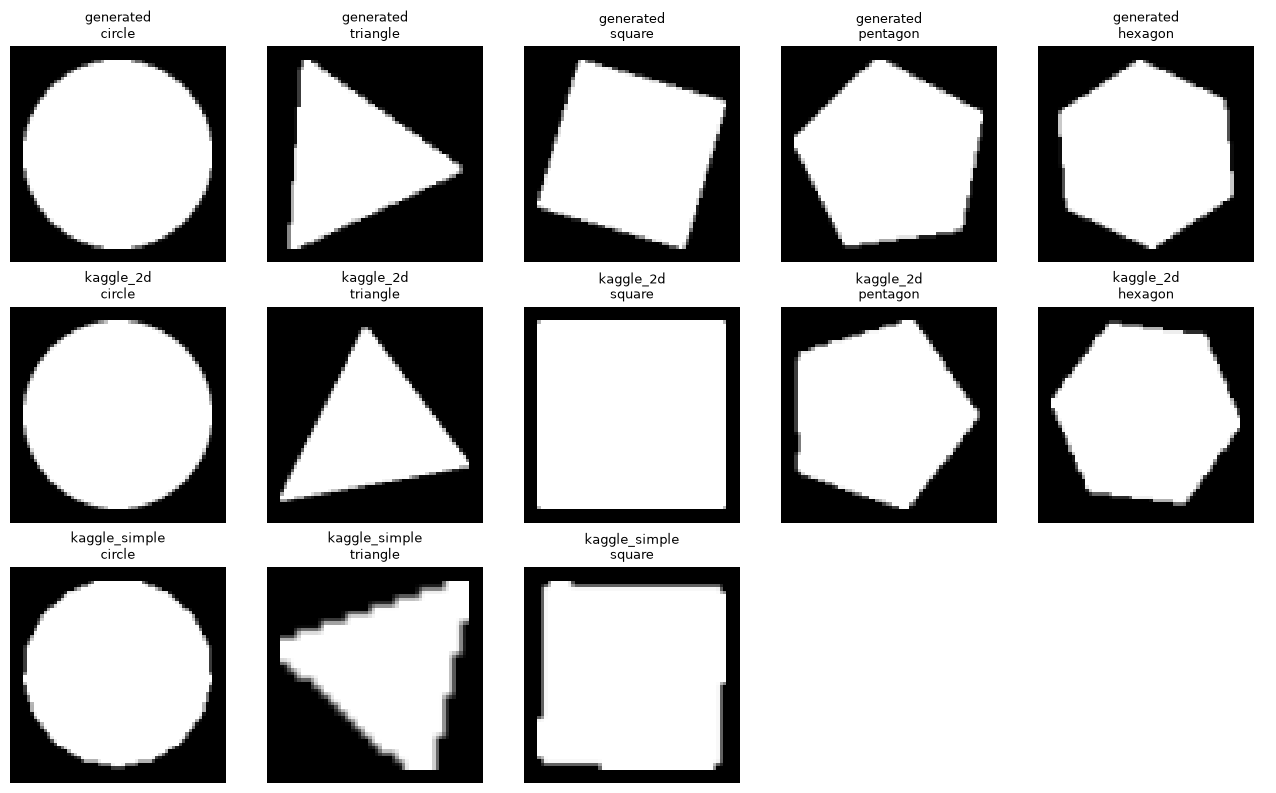

In [7]:
fig, axes = plt.subplots(3, 5, figsize=(13, 8))
for r, src in enumerate(["generated", "kaggle_2d", "kaggle_simple"]):
    for c, lab in enumerate(CLASSES):
        ax = axes[r, c]
        sub = data[(data.source == src) & (data.label == lab)]
        if sub.empty:
            ax.axis("off")
            continue
        ax.imshow(X[sub.index[0]], cmap="gray")
        ax.set_title(f"{src}\n{lab}", fontsize=9)
        ax.axis("off")
plt.tight_layout()
plt.show()

In [8]:
os.makedirs("data/processed", exist_ok=True)
np.savez_compressed("data/processed/silhouettes_64.npz", X=X, y=y)
data.to_csv("data/processed/dataset.csv", index=False)